In [1]:
from sklearn.cluster import KMeans
from util import show_overview_for_value, draw_barplot, load_building_df

## DataFrame Setup


In [2]:
df_X = load_building_df(
    "TotW", "ASILO_20240208.csv", "PM5320", "ASILO.GEN", resample="min"
)

In [3]:
# number of clusters that we want to fit each bin into
n_clusters = 2

# used to determine which dates to plot
start = "2024-01-24"
end = "2024-01-31"

## Prima divisione: lun-ven e sab-dom

Come mostrato nei seguenti DataFrame di esempio, una netta differenza in valori esiste già tra i giorni compresi tra lunedì e venerdì e quelli compresi tra sabato e domenica, giustificando una iniziale suddivisione "manuale" che ci permette di analizzare le fasce orarie a partire da due gruppi distinti di dati.


In [4]:
df = load_building_df("TotW", "ED18_20240208.csv", "GAVAZZI_WM30", "ED18_CDZ")
show_overview_for_value(df, "TotW")

In [5]:
df = load_building_df("TotW", "ASILO_20240208.csv", "PM5320", "ASILO.GEN")
show_overview_for_value(df, "TotW")

In [6]:
df = load_building_df("TotW", "ED14_20240208.csv", "PM5320", "ARCH_FM")
show_overview_for_value(df, "TotW")

## Seconda divisione: clustering

A partire da uno dei due macrogruppi (lun-ven o sab-dom), ricerco un'ulteriore divisione con lo scopo di separare valori a riposo (baseline) da valori di lavoro, tramite l'uso del KMeans.


### Lunedì-Venerdì


/tmp/ipykernel_30551/2394881590.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays["label"] = KMeans(


<Axes: >

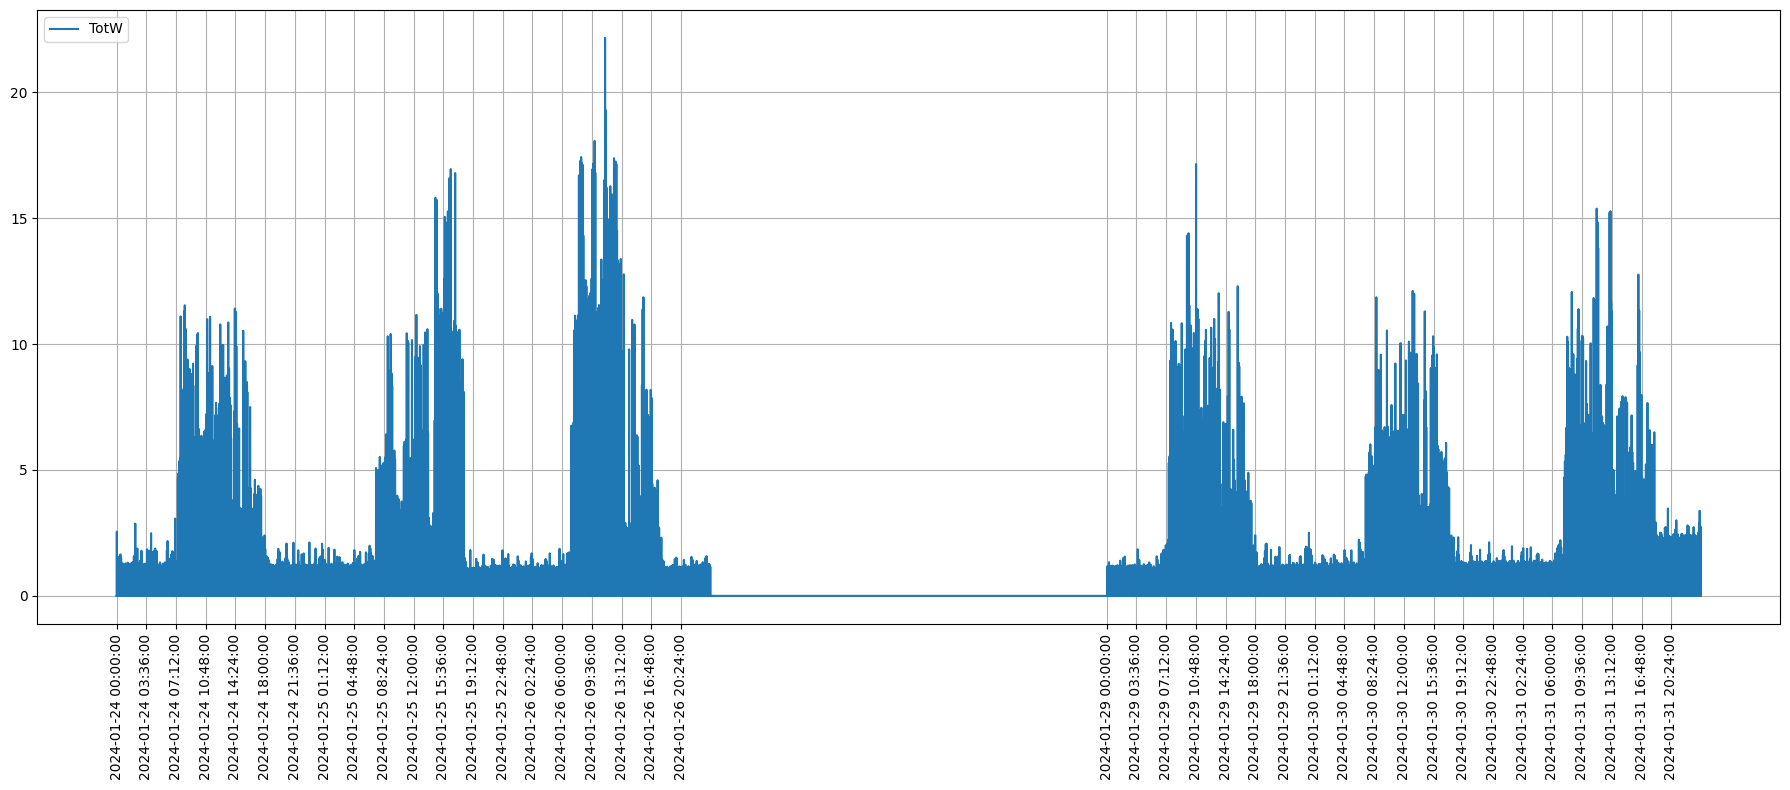

In [7]:
# Only days between monday (0) and friday(5)
from util import plot_dataframe


df_workdays = df_X[df_X["dayofweek"].isin(range(5))]

# Apply clustering
df_workdays["label"] = KMeans(
    n_init="auto", n_clusters=n_clusters, random_state=53
).fit_predict(df_workdays[["TotW"]])

# draw_barplot(
#     df_workdays.loc[start:end],
#     y="TotW",
#     x="datetime",
#     hue="label",
#     lw=0,
#     figsize=(20, 6),
#     visible_labels=False,
# )

plot_dataframe(df_workdays.loc[start:end], ["TotW"])

### Sabato-Domenica


In [8]:
# Only days between monday (0) and friday(5)
df_nonwork = df_X[df_X["dayofweek"].isin(range(5, 7))]

# Apply clustering
df_nonwork["label"] = KMeans(
    n_init="auto", n_clusters=n_clusters, random_state=53
).fit_predict(df_nonwork[["TotW"]])

# draw_barplot(
#     df_nonwork.loc["2023-11-22":"2023-12-07"],
#     y="TotW",
#     x="datetime",
#     hue="label",
#     lw=0,
#     figsize=(20, 6),
#     visible_labels=False,
# )

plot_dataframe(df_workdays.loc["2023-11-22":"2023-12-07"], ["TotW"])

/tmp/ipykernel_30551/39079344.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonwork["label"] = KMeans(
/home/impasse/Code/Projects/tirocinio_CSTE/tirocinio_cste/util.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: xlabel='datetime', ylabel='TotW'>,
 <Axes: xlabel='datetime', ylabel='TotW'>)

In [ ]:
# Assuming df_workdays is your DataFrame with the given structure
df_nonwork = df_nonwork.loc["2023-11-22":"2023-12-07"]

draw_barplot(
    df_nonwork.loc["2023-11-22":"2023-12-07"],
    y="TotW",
    x="datetime",
    hue="label",
    lw=0,
    figsize=(20, 6),
    visible_labels=False,
)

/home/impasse/Code/Projects/tirocinio_CSTE/tirocinio_cste/util.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: xlabel='datetime', ylabel='TotW'>,
 <Axes: xlabel='datetime', ylabel='TotW'>)

## Estrazione della baseline

Con questa ulteriore divisione via clustering, è possibile estrarre la baseline, di cui è mostrata un'overview di seguito.


In [ ]:
show_overview_for_value(df_workdays[df_workdays["label"] == 0], "TotW")

In [ ]:
show_overview_for_value(df_nonwork[df_nonwork["label"] == 0], "TotW")

## Fasce orarie


In [ ]:
df_timeslots = df_workdays.rename({"label": "count"}, axis=1)[["count", "hour"]]
time_dist = [
    df_timeslots[df_timeslots["count"] == i].groupby("hour").count()
    for i in range(n_clusters)
]

# Add empty slots for missing hours
for d in time_dist:
    for i in range(24):
        try:
            d.loc[i]
        except IndexError:
            d.loc[i] = 0

    d.sort_index(inplace=True)

/home/impasse/Code/Projects/tirocinio_CSTE/tirocinio_cste/util.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)
/home/impasse/Code/Projects/tirocinio_CSTE/tirocinio_cste/util.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=df.index, rotation=rotation)


(<Axes: title={'center': 'Distribuzione del tempo speso a regime'}, xlabel='hour', ylabel='count'>,
 <Axes: title={'center': 'Distribuzione del tempo speso a regime'}, xlabel='hour', ylabel='count'>)

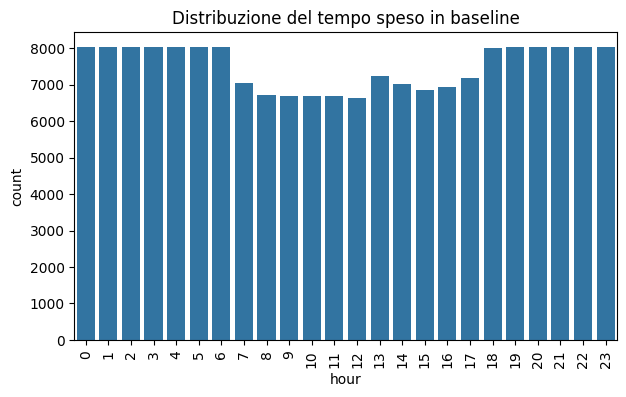

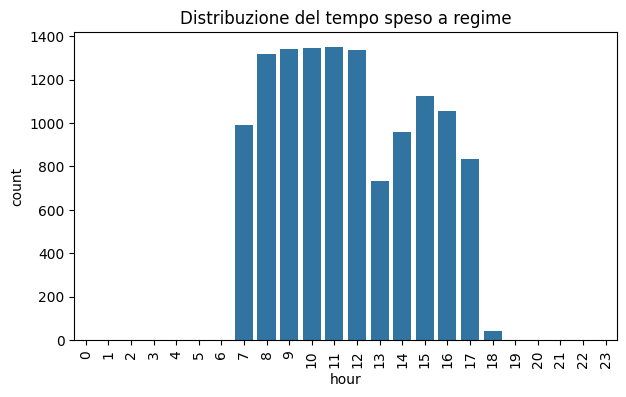

In [ ]:
draw_barplot(
    time_dist[0],
    time_dist[0].index,
    time_dist[0]["count"],
    figsize=(7, 4),
    title="Distribuzione del tempo speso in baseline",
)
draw_barplot(
    time_dist[1],
    time_dist[1].index,
    time_dist[1]["count"],
    figsize=(7, 4),
    title="Distribuzione del tempo speso a regime",
)